# Kiểm tra end-to-end pipeline nhận diện bãi xe

Chạy thử toàn bộ chuỗi xử lý trên ảnh thô (chưa cắt sẵn), không chỉ từng module riêng lẻ như các script `eval_*.py` hiện có:

```
ảnh thô
  ├─> [xe]   YOLOv8n (COCO) cắt vùng xe lớn nhất -> loại xe thô (car/motorcycle/bus/truck)
  │           └─ nếu car: model kiểu dáng (ResNet18/MobileNetV3-Small) -> Sedan/GamCao/XeTai
  └─> [biển] PlateDetector (YOLO huấn luyện trên A1) -> từng biển phát hiện được
             ├─ plate_color.process_plate -> màu biển + ảnh đã tăng cường cho OCR
             └─ CRNNRecognizer + read_plate -> chuỗi biển số đã chuẩn hoá
```

Notebook này chỉ **ghép lại** các hàm/class đã có sẵn (`predict_vehicle.py`, `plate_detection_pipeline`, `plate_color_pipeline`, `pipeline/ocr.py`), không viết lại logic xử lý nào. Notebook không train, không đo benchmark tốc độ (việc đó thuộc Tuần 7-8 theo đề cương). Mục tiêu duy nhất ở đây là kiểm tra pipeline chạy đúng, không lỗi, trên nhiều ảnh mẫu cùng lúc.

Toàn bộ đường dẫn model nằm gọn trong 1 cell cấu hình ngay bên dưới. Đổi model/seed hay đổi thư mục ảnh test chỉ cần sửa ở đó, không phải sửa code phía dưới.

In [1]:
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[2] if (Path.cwd().name == "notebooks") else Path.cwd()
ML_DIR = REPO_ROOT / "src" / "ml"

# ============================================================
# CẤU HÌNH ĐƯỜNG DẪN MODEL: sửa ở đây, không sửa code bên dưới
# ============================================================

# --- Phát hiện xe thô (pretrained COCO, không cần huấn luyện thêm) ---
VEHICLE_COARSE_WEIGHTS = ML_DIR / "weights" / "yolov8n.pt"

# --- Phân loại kiểu dáng xe con ---
VEHICLE_STYLE_MODEL = "resnet18"  # hoặc "mobilenet_v3_small"

# --- Phát hiện biển số (YOLO huấn luyện trên A1) ---
# Bản mặc định là bản tốt nhất theo src/ml/experiments.csv (mAP50 0.9892,
# tốt hơn yolo26n_s0_640 0.9801). Đổi sang model/seed khác đã giải nén từ
# Drive (yolov8n_s1_640, yolov8n_s2_640, yolo26n_s0_640, ...) nếu muốn so sánh.
# Bản .onnx, xuất từ bản tốt nhất theo src/ml/experiments.csv (mAP50 0.9892,
# tốt hơn yolo26n_s0_640 0.9801). Đây là bản duy nhất được track trong git
# (output/runs/ bị .gitignore chặn hoàn toàn), nên đồng bộ giữa các máy qua
# git, không phải chuyển tay. Khớp bản .pt trên 16/17 ảnh testimage/ (1 ca
# lệch là biển rất nhỏ/xa ở rìa ngưỡng tin cậy, không phải lỗi export).
PLATE_DETECTOR_WEIGHTS = ML_DIR / "plate_detection_pipeline" / "weights" / "yolov8n_a1_640.onnx"
PLATE_DETECTOR_BACKEND = "onnx"
PLATE_DETECTOR_CONF = 0.25

# --- OCR biển số (CRNN tự huấn luyện, bản chốt seed 42) ---
# Dùng .onnx: bản duy nhất được track trong git (.pt bị loại vì dung lượng),
# nên đồng bộ giữa các máy qua git, và chạy suy luận không cần torch.
OCR_WEIGHTS = ML_DIR / "weights" / "plate-ocr-crnn.onnx"

# --- Ảnh test: chạy được nhiều ảnh 1 lần, không giới hạn 1 ảnh ---
# Mặc định dùng bộ ảnh test thật trong testimage/ (repo root), ảnh do nhóm
# tự chụp/sưu tầm, không phải crop sẵn của A1, sát điều kiện triển khai hơn.
TEST_IMAGE_DIR = REPO_ROOT / "testimage"
# Đổi lại thành None nếu muốn quay về mặc định cũ
# (data/raw/kaggle_vn_plate_segment/images/val/), hoặc điền thư mục khác.
N_SAMPLES = 20          # testimage/ hiện có 8 ảnh, đặt lớn hơn số ảnh thật để lấy hết, không lỗi
SEED = 11               # cố định để lặp lại được cùng 1 tập mẫu giữa các lần chạy

print("REPO_ROOT:", REPO_ROOT)
print("Vehicle coarse weights tồn tại:", VEHICLE_COARSE_WEIGHTS.exists())
print("Plate detector weights tồn tại:", PLATE_DETECTOR_WEIGHTS.exists())
print("OCR weights tồn tại:", OCR_WEIGHTS.exists())

REPO_ROOT: E:\Learn\UIT\UIT2026-DoAnCuoiKi
Vehicle coarse weights tồn tại: True
Plate detector weights tồn tại: True
OCR weights tồn tại: True


In [2]:
import sys

# Cho import trực tiếp từ các package/script hiện có, không cần pip install -e
for p in (
    ML_DIR,                                 # pipeline/, predict_vehicle.py
    ML_DIR / "training",                    # ocr_model.py, classifier.py
    ML_DIR / "plate_detection_pipeline",    # gói plate_detect
    ML_DIR / "plate_color_pipeline",        # gói plate_color
):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import random

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

from predict_vehicle import detect_vehicle_crop, load_style_model
from classifier import build_transforms
from plate_detect.inference.plate_detector import PlateDetector
from plate_color import process_plate
from pipeline.ocr import CRNNRecognizer, read_plate

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
if not PLATE_DETECTOR_WEIGHTS.exists():
    raise FileNotFoundError(
        f"Không thấy {PLATE_DETECTOR_WEIGHTS}.\n"
        "Tải output huấn luyện biển số từ link Drive ở "
        "src/ml/plate_detection_pipeline/output/README.MD, giải nén vào "
        "src/ml/plate_detection_pipeline/output/, rồi chạy lại cell này "
        "(hoặc đổi PLATE_DETECTOR_WEIGHTS ở cell cấu hình sang 1 file đã có sẵn)."
    )

plate_detector = PlateDetector(
    str(PLATE_DETECTOR_WEIGHTS), backend=PLATE_DETECTOR_BACKEND, conf=PLATE_DETECTOR_CONF,
)
ocr_recognizer = CRNNRecognizer(OCR_WEIGHTS, device=DEVICE)
style_model, style_classes = load_style_model(VEHICLE_STYLE_MODEL, DEVICE)
style_transform = build_transforms(train=False)

print("Đã load xong: plate detector, OCR, phân loại kiểu dáng xe.")
print("Lớp kiểu dáng:", style_classes)

Đã load xong: plate detector, OCR, phân loại kiểu dáng xe.
Lớp kiểu dáng: ['GamCao', 'Sedan', 'XeTai']


In [4]:
default_dir = REPO_ROOT / "data" / "raw" / "kaggle_vn_plate_segment" / "images" / "val"
image_dir = Path(TEST_IMAGE_DIR) if TEST_IMAGE_DIR else default_dir

all_images = sorted(p for p in image_dir.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png"))
if not all_images:
    raise FileNotFoundError(f"Không tìm thấy ảnh nào trong {image_dir}")

sample_images = random.Random(SEED).sample(all_images, min(N_SAMPLES, len(all_images)))
print(f"Chọn {len(sample_images)} ảnh từ {image_dir}:")
for p in sample_images:
    print(" -", p.name)

Chọn 16 ảnh từ E:\Learn\UIT\UIT2026-DoAnCuoiKi\testimage:
 - xanh.jpg
 - tai-xe-xanhdocx-1703647082801.jpg
 - t1.png
 - t6.jpg
 - m_1742218055.685.jpg
 - t5.png
 - xemay293_jpg.rf.121ce8b2f08635a956b6b602c648b9a1.jpg
 - CarLongPlate379_jpg.rf.c58c0b88e6bfa8bdff38e217b0f3fef9.jpg
 - CarLongPlate306_jpg.rf.689a7d4f2808bfdc31fbe69fa37b2c77.jpg
 - Hung_0025.png
 - Dieu_0017.png
 - t2.png
 - 068.jpg
 - 0043_01757_b.jpg
 - Dieu_0237.png
 - t3.png


## Chạy pipeline

Model chỉ load 1 lần ở cell trên, dùng lại cho tất cả `N_SAMPLES` ảnh.

In [5]:
def run_pipeline_on_image(image_path: Path) -> tuple[dict, np.ndarray]:
    """Chạy toàn bộ chuỗi trên 1 ảnh thô. Trả về (kết quả, ảnh gốc BGR)."""
    img_bgr = cv2.imread(str(image_path))
    img_pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    result = {
        "file": image_path.name,
        "vehicle_type": None, "vehicle_box": None,
        "vehicle_style": None, "vehicle_style_conf": None,
        "plates": [],
    }

    # --- Nhánh xe: phát hiện thô + (nếu là car) phân loại kiểu dáng ---
    crop_pil, det_info = detect_vehicle_crop(img_pil)
    if det_info is not None:
        result["vehicle_type"] = det_info["yolo_class"]
        result["vehicle_box"] = det_info["box"]
        if det_info["yolo_class"] == "car":
            x = style_transform(crop_pil).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                probs = torch.softmax(style_model(x), dim=1)[0]
            idx = int(probs.argmax())
            result["vehicle_style"] = style_classes[idx]
            result["vehicle_style_conf"] = probs[idx].item()

    # --- Nhánh biển số: phát hiện -> màu + tăng cường -> OCR, cho từng biển ---
    for det in plate_detector.detect(img_bgr):
        appearance = process_plate(det.crop)
        reading = read_plate(appearance.crop_for_ocr, ocr_recognizer, layout=det.cls_name)
        result["plates"].append({
            "bbox": det.bbox_xyxy, "layout": det.cls_name, "det_conf": det.conf,
            "plate_text": reading.text_display, "plate_valid": reading.valid_format,
            "ocr_conf": reading.confidence,
            "color": appearance.color, "color_conf": appearance.color_conf,
        })

    return result, img_bgr


results, annotated_source_images = [], []
for img_path in sample_images:
    res, img_bgr = run_pipeline_on_image(img_path)
    results.append(res)
    annotated_source_images.append(img_bgr)

print(f"Đã chạy xong pipeline trên {len(results)} ảnh.")

Đã chạy xong pipeline trên 16 ảnh.


In [6]:
for res in results:
    print(f"=== {res['file']} ===")
    vehicle_line = f"  Xe: {res['vehicle_type'] or '(không phát hiện)'}"
    if res["vehicle_style"]:
        vehicle_line += f" - kiểu dáng {res['vehicle_style']} ({res['vehicle_style_conf']:.1%})"
    print(vehicle_line)

    if not res["plates"]:
        print("  (không phát hiện được biển số nào)")
    for i, p in enumerate(res["plates"], 1):
        flag = "OK" if p["plate_valid"] else "!! không khớp định dạng biển VN"
        print(
            f"  Biển {i}: {p['plate_text']}  [{flag}]  "
            f"màu={p['color']} ({p['color_conf']:.1%})  "
            f"det_conf={p['det_conf']:.2f}  ocr_conf={p['ocr_conf']:.2f}  "
            f"layout={p['layout']}"
        )
    print()

=== xanh.jpg ===
  Xe: car - kiểu dáng Sedan (100.0%)
  Biển 1: 51A-0718  [OK]  màu=blue (76.8%)  det_conf=0.88  ocr_conf=0.99  layout=bien_2hang
  Biển 2: 629297540  [!! không khớp định dạng biển VN]  màu=white (94.3%)  det_conf=0.65  ocr_conf=0.93  layout=bien_2hang

=== tai-xe-xanhdocx-1703647082801.jpg ===
  Xe: car - kiểu dáng Sedan (98.2%)
  Biển 1: 50E-101.59  [OK]  màu=yellow (95.5%)  det_conf=0.92  ocr_conf=0.99  layout=bien_2hang

=== t1.png ===
  Xe: motorcycle
  Biển 1: 60S6-7137  [OK]  màu=white (95.2%)  det_conf=0.89  ocr_conf=0.99  layout=bien_2hang

=== t6.jpg ===
  Xe: truck
  Biển 1: 29E-063.75  [OK]  màu=yellow (86.1%)  det_conf=0.93  ocr_conf=0.98  layout=bien_2hang

=== m_1742218055.685.jpg ===
  Xe: car - kiểu dáng Sedan (42.9%)
  Biển 1: 30M-055.91  [OK]  màu=white (98.5%)  det_conf=0.88  ocr_conf=0.98  layout=bien_1hang

=== t5.png ===
  Xe: motorcycle
  Biển 1: 99F3-2294  [OK]  màu=white (74.4%)  det_conf=0.90  ocr_conf=0.99  layout=bien_2hang

=== xemay293_jpg

## Trực quan hoá

Cam: bbox xe (kèm loại xe/kiểu dáng). Xanh lá: biển đọc được khớp định dạng biển số VN. Đỏ: biển phát hiện được nhưng chuỗi đọc ra không khớp định dạng (đáng nghi, cần xem lại bằng mắt).

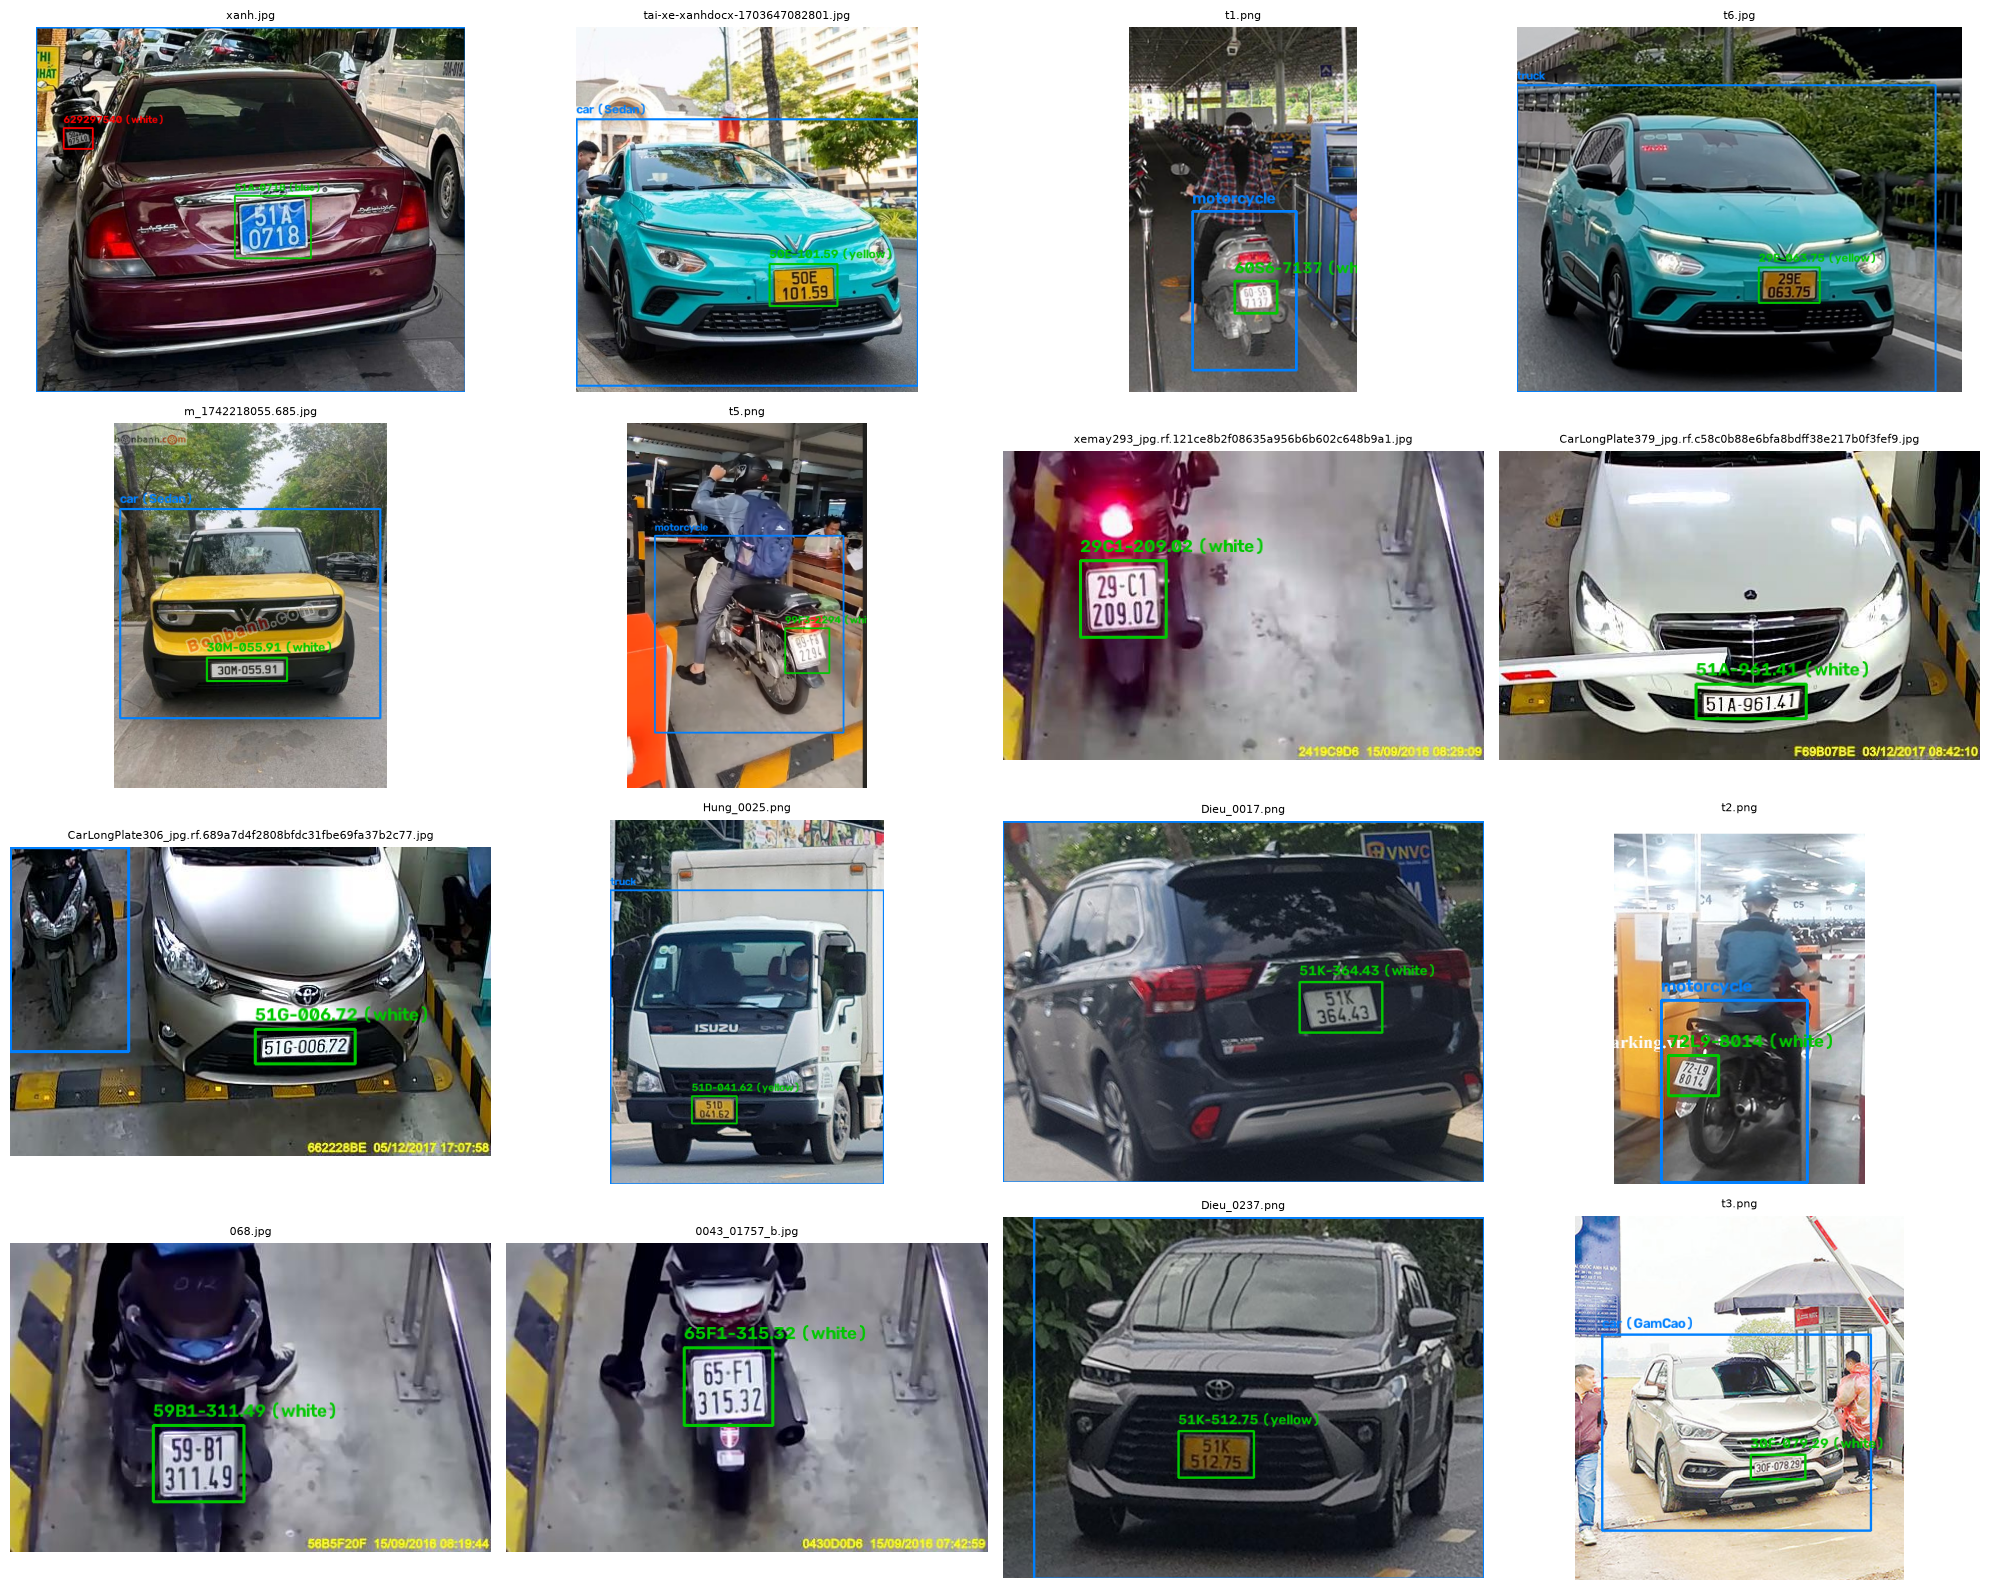

In [7]:
def draw_annotations(img_bgr: np.ndarray, result: dict) -> np.ndarray:
    img = img_bgr.copy()
    if result["vehicle_box"]:
        x1, y1, x2, y2 = result["vehicle_box"]
        label = result["vehicle_type"] or "?"
        if result["vehicle_style"]:
            label += f" ({result['vehicle_style']})"
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 128, 0), 2)
        cv2.putText(img, label, (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 128, 0), 2)

    for plate in result["plates"]:
        x1, y1, x2, y2 = plate["bbox"]
        text = f"{plate['plate_text']} ({plate['color']})"
        color = (0, 200, 0) if plate["plate_valid"] else (0, 0, 255)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, text, (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img


n = len(results)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.atleast_1d(axes).flatten()
for ax, res, img_bgr in zip(axes, results, annotated_source_images):
    annotated = draw_annotations(img_bgr, res)
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(res["file"], fontsize=8)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Bảng tổng hợp

1 dòng / biển phát hiện được (1 ảnh có thể ra nhiều dòng nếu nhiều biển, hoặc 1 dòng ghi chú nếu không phát hiện được biển nào), để rà lỗi hàng loạt nhanh hơn nhìn từng ảnh.

In [8]:
rows = []
for res in results:
    base = {
        "file": res["file"], "vehicle_type": res["vehicle_type"],
        "vehicle_style": res["vehicle_style"],
    }
    if res["plates"]:
        for p in res["plates"]:
            rows.append({
                **base,
                "plate_layout": p["layout"], "plate_text": p["plate_text"],
                "plate_valid": p["plate_valid"], "plate_color": p["color"],
                "det_conf": round(p["det_conf"], 3), "ocr_conf": round(p["ocr_conf"], 3),
            })
    else:
        rows.append({
            **base,
            "plate_layout": None, "plate_text": "(không phát hiện được biển)",
            "plate_valid": False, "plate_color": None,
            "det_conf": None, "ocr_conf": None,
        })

summary_df = pd.DataFrame(rows)
summary_df

,file,vehicle_type,vehicle_style,plate_layout,plate_text,plate_valid,plate_color,det_conf,ocr_conf
0,xanh.jpg,car,Sedan,bien_2hang,51A-0718,True,blue,0.878,0.986
1,xanh.jpg,car,Sedan,bien_2hang,629297540,False,white,0.647,0.930
2,tai-xe-xanhdocx-1703647082801.jpg,car,Sedan,bien_2hang,50E-101.59,True,yellow,0.924,0.995
3,t1.png,motorcycle,NaN,bien_2hang,60S6-7137,True,white,0.891,0.992
4,t6.jpg,truck,NaN,bien_2hang,29E-063.75,True,yellow,0.925,0.981
5,m_1742218055.685.jpg,car,Sedan,bien_1hang,30M-055.91,True,white,0.884,0.981
6,t5.png,motorcycle,NaN,bien_2hang,99F3-2294,True,white,0.904,0.985
7,xemay293_jpg.rf.121ce8b2f08635a956b6b602c648b9...,NaN,NaN,bien_2hang,29C1-209.02,True,white,0.923,0.977
8,CarLongPlate379_jpg.rf.c58c0b88e6bfa8bdff38e21...,NaN,NaN,bien_1hang,51A-961.41,True,white,0.894,0.985
9,CarLongPlate306_jpg.rf.689a7d4f2808bfdc31fbe69...,motorcycle,NaN,bien_1hang,51G-006.72,True,white,0.901,0.982
